# Coral Reef Bleaching — SVM (RBF Kernel)
**Member 4 | ML Assignment | SLIIT**

**GPU Strategy:** RAPIDS cuML `SVC` on T4 GPU.
Falls back to `sklearn.svm.SVC` with `cache_size=2000` if cuML unavailable.

**Why SVM with RBF Kernel?**
The SST-to-bleaching relationship is non-linear (threshold effect ~30°C).
The RBF kernel maps data into higher-dimensional space where a linear boundary
captures this threshold naturally. Maximum margin principle makes SVM robust
to noise in field-collected reef survey data.

**Dataset:** Global Coral Bleaching Database (1980–2020) | BCO-DMO
**DOI:** https://doi.org/10.26008/1912/bco-dmo.773466.2
**License:** Creative Commons Attribution 4.0


## 0. Runtime & GPU Setup
**Before running:** `Runtime` → `Change runtime type` → **T4 GPU** → Save → `Run all`

In [1]:
import subprocess, sys, os, platform, time, multiprocessing

REQUIRED_PKGS = ["scikit-learn","pandas","numpy","matplotlib","seaborn","joblib","opendatasets"]
for pkg in REQUIRED_PKGS:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])

IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

GPU_AVAILABLE = False
GPU_NAME      = "None"
GPU_MEM_MB    = 0
try:
    r = subprocess.run(
        ["nvidia-smi","--query-gpu=name,memory.total","--format=csv,noheader"],
        capture_output=True, text=True, timeout=5)
    if r.returncode == 0 and r.stdout.strip():
        parts      = r.stdout.strip().split(",")
        GPU_NAME   = parts[0].strip()
        GPU_MEM_MB = int(parts[1].strip().replace("MiB","").strip())
        GPU_AVAILABLE = True
except Exception:
    pass

CUML_AVAILABLE = False
if GPU_AVAILABLE and IN_COLAB:
    print("T4 GPU detected — installing RAPIDS cuML...")
    try:
        subprocess.run(
            [sys.executable,"-m","pip","install",
             "--extra-index-url=https://pypi.nvidia.com",
             "cudf-cu12","cuml-cu12","--quiet"],
            capture_output=True, text=True, timeout=300)
        import cuml
        CUML_AVAILABLE = True
        print("cuML installed — GPU ML enabled!")
    except Exception as e:
        print(f"cuML install failed ({e}) — using CPU sklearn fallback")
elif GPU_AVAILABLE:
    try:
        import cuml
        CUML_AVAILABLE = True
    except ImportError:
        pass

N_CPUS = multiprocessing.cpu_count()
N_JOBS = -1
RANDOM_STATE = 42

print("=" * 55)
print("  RUNTIME SUMMARY")
print("=" * 55)
print(f"  Platform : {'Google Colab' if IN_COLAB else platform.system()}")
print(f"  GPU      : {GPU_NAME if GPU_AVAILABLE else 'Not available'}")
print(f"  GPU Mem  : {GPU_MEM_MB} MiB" if GPU_AVAILABLE else "  GPU Mem  : N/A")
print(f"  cuML     : {'Available — GPU mode' if CUML_AVAILABLE else 'Not available — CPU mode'}")
print(f"  CPU cores: {N_CPUS}")
print("=" * 55)
if not GPU_AVAILABLE:
    print("  No GPU found. Runtime -> Change runtime type -> T4 GPU")


Installing scikit-learn...
Installing opendatasets...
T4 GPU detected — installing RAPIDS cuML...
cuML installed — GPU ML enabled!
  RUNTIME SUMMARY
  Platform : Google Colab
  GPU      : Tesla T4
  GPU Mem  : 15360 MiB
  cuML     : Available — GPU mode
  CPU cores: 2


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
print("Libraries loaded.")


Libraries loaded.


## 2. Download Dataset

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

LOCAL_FILE  = "global_bleaching_environmental.csv"
PRIMARY_URL = "https://datadocs.bco-dmo.org/dataset/773466/file/B11vA82u7y2Owp/global_bleaching_environmental.csv"
KAGGLE_DS   = "mehrdat/coral-reef-global-bleaching"

def download_dataset():
    if os.path.exists(LOCAL_FILE):
        print("Found local file:", LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        return df
    print("Downloading from BCO-DMO...")
    try:
        import urllib.request
        urllib.request.urlretrieve(PRIMARY_URL, LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        df.to_csv(LOCAL_FILE, index=False)
        print("Downloaded:", len(df), "rows")
        return df
    except Exception as e:
        print("BCO-DMO failed:", e)
    print("Trying Kaggle...")
    try:
        subprocess.check_call([sys.executable,"-m","pip","install","opendatasets","-q"])
        import opendatasets as od
        od.download(f"https://www.kaggle.com/datasets/{KAGGLE_DS}", data_dir=".", force=False)
        folder = KAGGLE_DS.split("/")[1]
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith(".csv"):
                    df = pd.read_csv(os.path.join(root,f), low_memory=False)
                    df.replace("nd", np.nan, inplace=True)
                    df.to_csv(LOCAL_FILE, index=False)
                    return df
    except Exception as e:
        print("Kaggle failed:", e)
    raise FileNotFoundError(
        "Auto-download failed. Download manually from:\n"
        "  https://www.bco-dmo.org/dataset/773466")

df = download_dataset()
print("Dataset shape:", df.shape)
df.head()


Downloaded: 41361 rows
Dataset shape: (41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


## 3. Exploratory Data Analysis

=== Missing Values (%) ===
Site_Comments         94.543169
Bleaching_Comments    93.547061
Sample_Comments       92.848335
Site_Name             83.240250
Bleaching_Level       45.525979
Substrate_Name        30.627886
Reef_ID               30.318416
Percent_Cover         30.112908
Percent_Bleaching     16.551824
Depth_m                4.349508


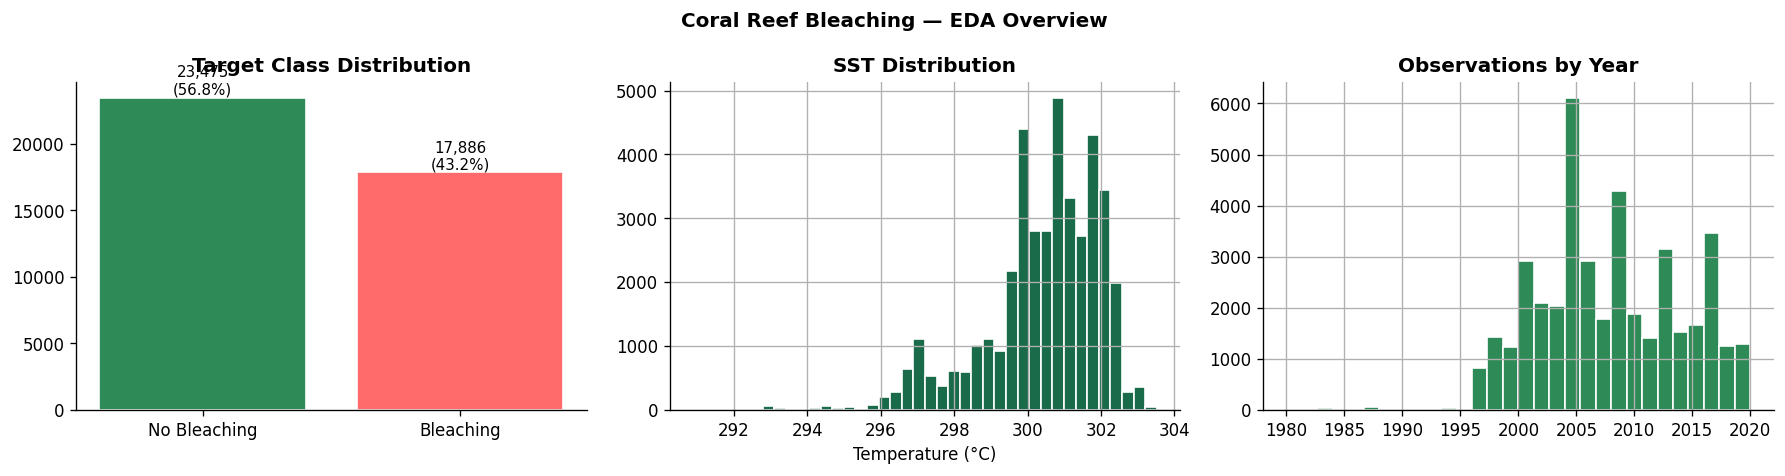

EDA complete.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("=== Missing Values (%) ===")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10).to_string())

sst_col    = next((c for c in df.columns if "temperature_mean" in c.lower()), None) or              next((c for c in df.columns if "sst" in c.lower() and "anom" not in c.lower()), None)
bleach_col = next((c for c in df.columns if "percent_bleach" in c.lower()), None)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Coral Reef Bleaching — EDA Overview", fontweight="bold")

if bleach_col:
    df[bleach_col] = pd.to_numeric(df[bleach_col], errors="coerce")
    binary = (df[bleach_col] > 0).astype(int)
    vc = binary.value_counts()
    axes[0].bar(["No Bleaching","Bleaching"], vc.values,
                color=["#2E8B57","#FF6B6B"], edgecolor="white")
    axes[0].set_title("Target Class Distribution", fontweight="bold")
    for i, v in enumerate(vc.values):
        axes[0].text(i, v*1.01, f"{v:,}\n({v/len(binary)*100:.1f}%)", ha="center", fontsize=9)

if sst_col:
    df[sst_col] = pd.to_numeric(df[sst_col], errors="coerce")
    df[sst_col].dropna().hist(ax=axes[1], bins=40, color="#1A6B4A", edgecolor="white")
    axes[1].set_title(f"SST Distribution", fontweight="bold")
    axes[1].set_xlabel("Temperature (°C)")

yr_col = next((c for c in df.columns if "year" in c.lower()), None)
if yr_col:
    df[yr_col] = pd.to_numeric(df[yr_col], errors="coerce")
    df[yr_col].dropna().hist(ax=axes[2], bins=30, color="#2E8B57", edgecolor="white")
    axes[2].set_title("Observations by Year", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()
print("EDA complete.")


## 4. Data Preprocessing
Same pipeline across all 4 notebooks — `random_state=42` ensures identical splits.

Target: Bleaching_Binary | Distribution: {1: np.int64(17886), 0: np.int64(16629)}
Features selected: 16 ['ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW', 'Windspeed', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'Turbidity', 'Cyclone_Frequency', 'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']


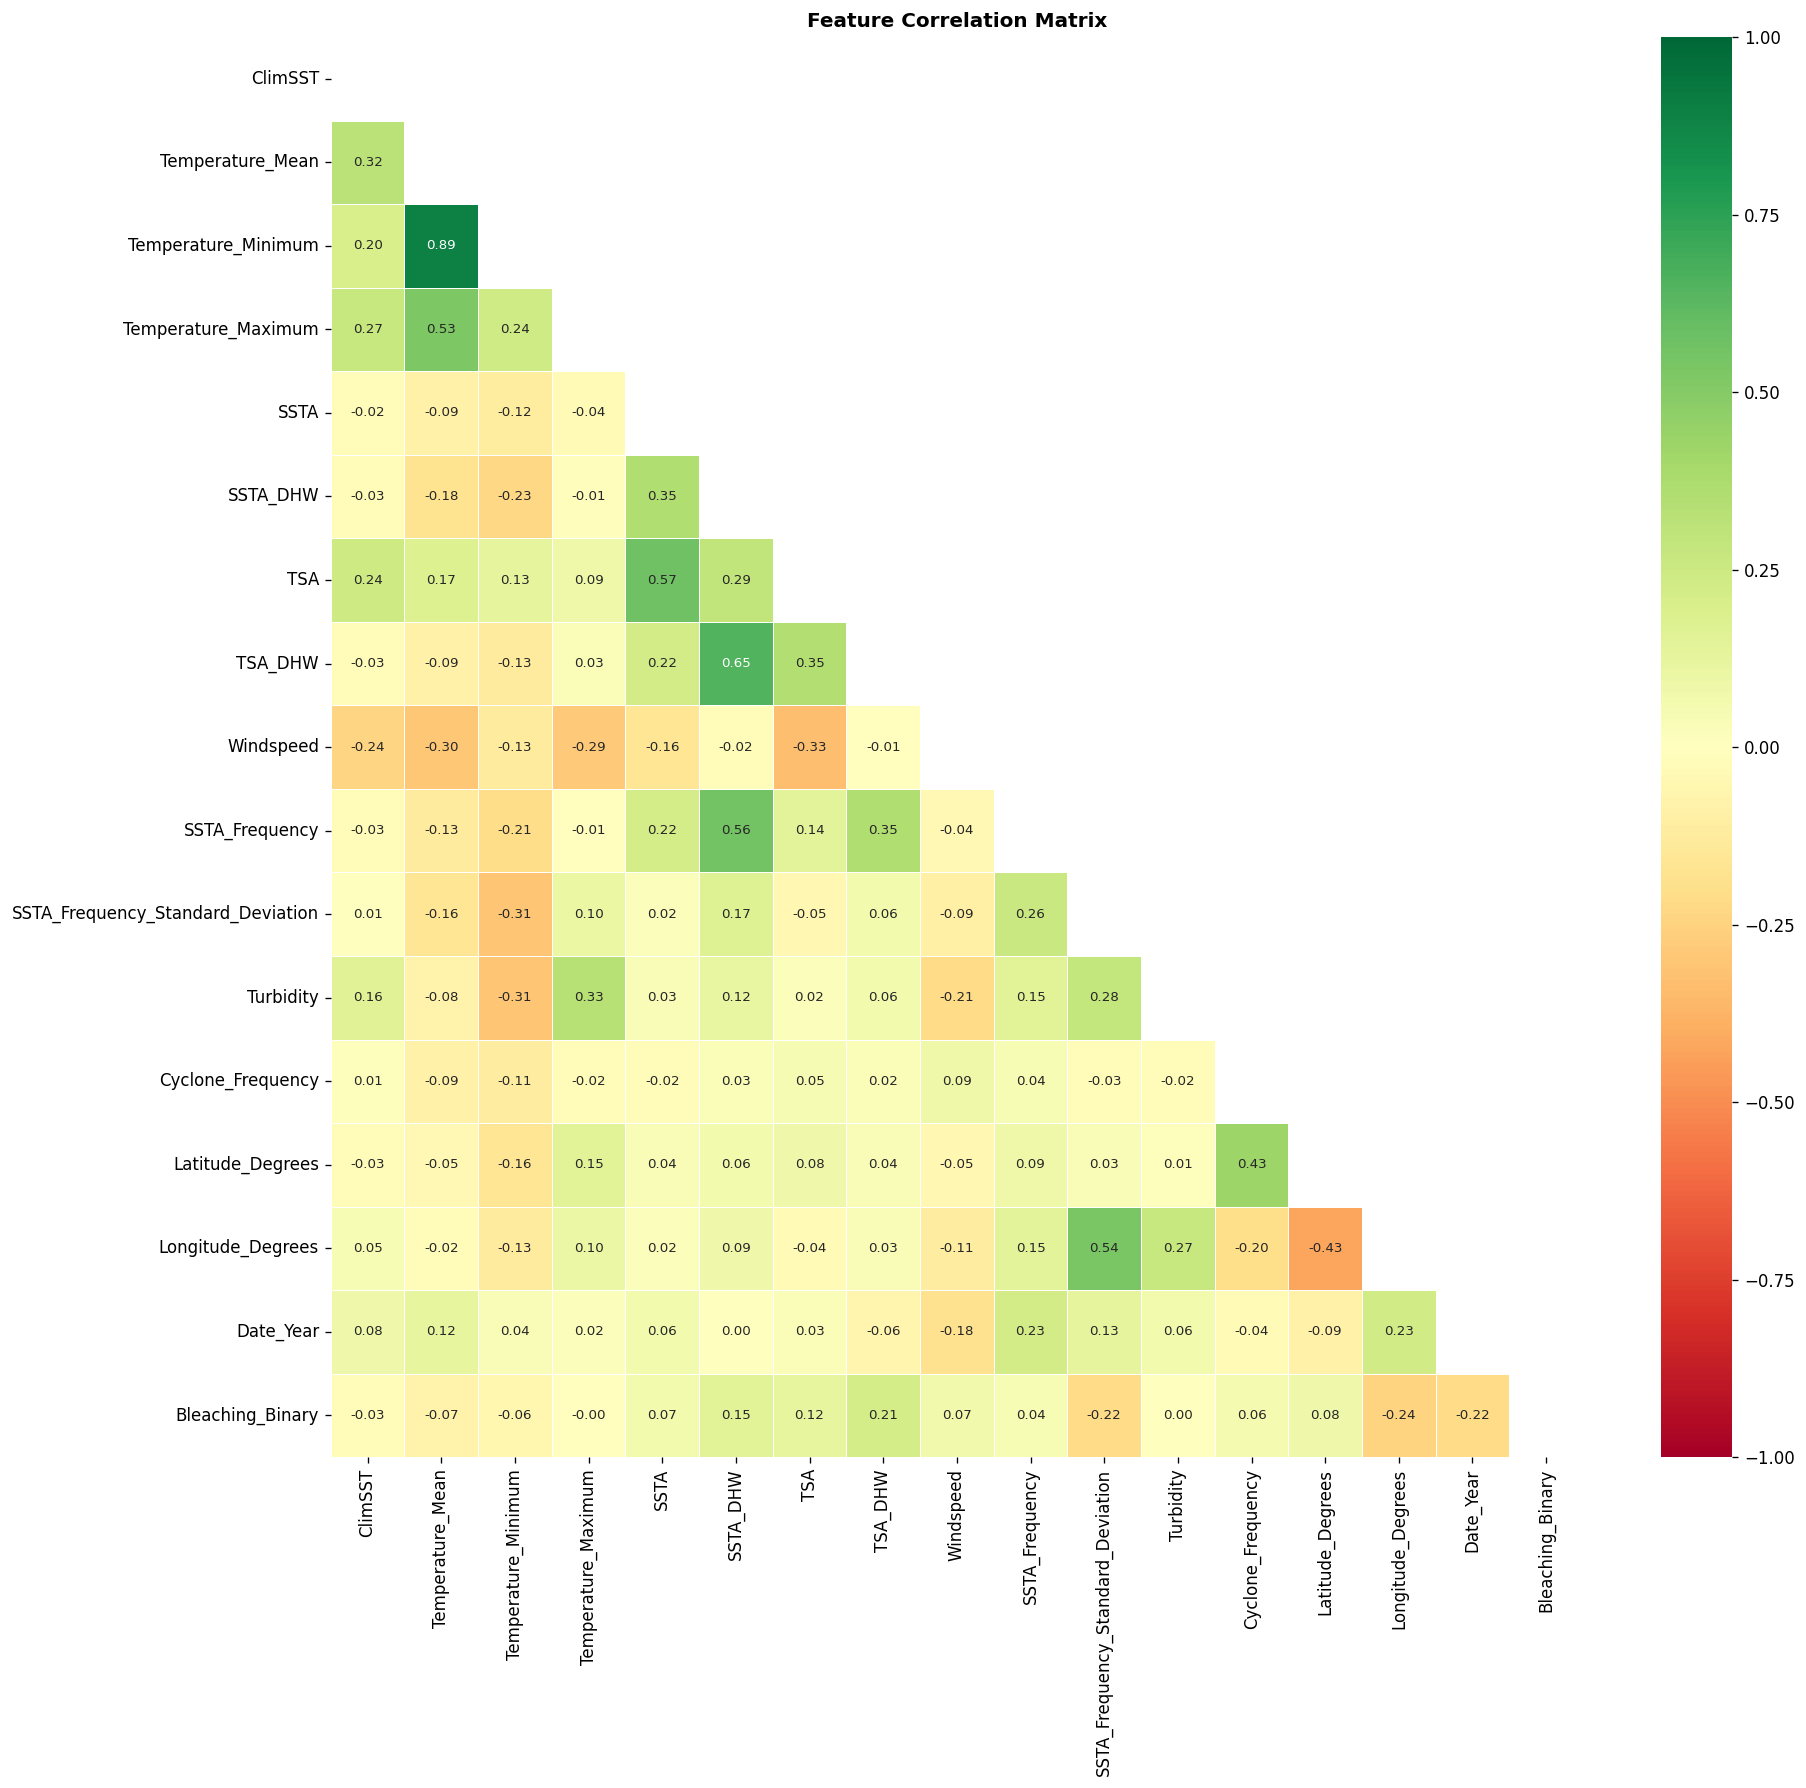

Train: 27612 | Test: 6903
Class balance train: {1: np.int64(14309), 0: np.int64(13303)}


In [5]:
df.replace("nd", np.nan, inplace=True)

BLEACH_COL = next(
    (c for c in df.columns if "percent_bleach" in c.lower()),
    next((c for c in df.columns if "bleach" in c.lower() and
          pd.to_numeric(df[c], errors="coerce").notna().mean() > 0.3), None))
if BLEACH_COL is None:
    raise ValueError("Cannot find bleaching column. Columns: " + str(list(df.columns)))

df[BLEACH_COL] = pd.to_numeric(df[BLEACH_COL], errors="coerce")
df.dropna(subset=[BLEACH_COL], inplace=True)
TARGET = "Bleaching_Binary"
df[TARGET] = (df[BLEACH_COL] > 0).astype(int)
print("Target:", TARGET, "| Distribution:", dict(df[TARGET].value_counts()))

CANDIDATES = [
    "ClimSST","Temperature_Mean","Temperature_Minimum","Temperature_Maximum",
    "SSTA","SSTA_DHW","TSA","TSA_DHW","TSA_DHW_Frequency",
    "Windspeed","SSTA_Frequency","SSTA_Frequency_Standard_Deviation",
    "Turbidity_ct","Turbidity","Cyclone_Frequency",
    "Distance","Depth","Latitude_Degrees","Longitude_Degrees","Date_Year",
]
FEATURES = []
for col in CANDIDATES:
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce")
        if vals.notna().mean() > 0.2:
            FEATURES.append(col)

if not FEATURES:
    SKIP = {BLEACH_COL, TARGET, "Reef_ID","Site_ID","Sample_ID","ID","id",
            "Date","Country_Name","City_Town_Name","Site_Name","Data_Source",
            "Ocean_Name","Realm_Name","Ecoregion_Name","Exposure","Bleaching_Level"}
    for col in df.columns:
        if col in SKIP: continue
        vals = pd.to_numeric(df[col], errors="coerce")
        if vals.notna().mean() > 0.2:
            FEATURES.append(col)

print("Features selected:", len(FEATURES), FEATURES)

df_model = df[FEATURES + [TARGET]].copy()
for col in FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

for col in FEATURES:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

for col in FEATURES:
    Q1, Q3 = df_model[col].quantile(0.25), df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        df_model[col] = df_model[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

low_var = [c for c in FEATURES if df_model[c].std() < 1e-6]
if low_var:
    FEATURES = [f for f in FEATURES if f not in low_var]
    df_model.drop(columns=low_var, inplace=True)

corr = df_model[FEATURES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.97)]
if to_drop:
    FEATURES = [f for f in FEATURES if f not in to_drop]
    df_model.drop(columns=to_drop, inplace=True)

plt.figure(figsize=(max(8, len(FEATURES)), max(6, len(FEATURES)-1)))
mask = np.triu(np.ones((len(FEATURES)+1, len(FEATURES)+1), dtype=bool))
sns.heatmap(df_model[FEATURES+[TARGET]].corr(), mask=mask, annot=True,
            fmt=".2f", cmap="RdYlGn", linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 8})
plt.title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

from sklearn.model_selection import train_test_split
X = df_model[FEATURES]
y = df_model[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Class balance train:", dict(y_train.value_counts()))


## 5. Feature Scaling — Mandatory for SVM
SVM computes distances in feature space. Without scaling, SST (20–35°C) dominates DHW (0–20) purely by magnitude — not importance.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_test_scaled  = scaler.transform(X_test)          # transform only — no data leakage

print("Scaling complete.")
print("  Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("  Train std  (should be ~1):", X_train_scaled.std(axis=0).round(2))


Scaling complete.
  Train mean (should be ~0): [-0.  0. -0. -0.  0.  0.  0. -0. -0.  0.  0.  0.  0.  0. -0.  0.]
  Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. GPU Model Selection
cuML SVC uses a GPU-accelerated SMO solver — much faster than sklearn SVC which is O(n²) and slow on 34K rows.

sklearn SVC fallback subsamples to 10K rows to keep training feasible on CPU.

In [7]:
# ── cuML GPU SVM ─────────────────────────────────────────────────────────────
if CUML_AVAILABLE:
    print("Using cuML SVC on GPU (T4)")
    from cuml.svm import SVC as CuSVC
    import cupy as cp

    X_tr_gpu = cp.array(X_train_scaled, dtype=cp.float32)
    X_te_gpu = cp.array(X_test_scaled,  dtype=cp.float32)
    y_tr_gpu = cp.array(y_train.values, dtype=cp.float32)

    SVM_CLASS   = CuSVC
    USE_GPU_SVM = True
    print("  Data on GPU:", X_tr_gpu.shape, X_tr_gpu.dtype)
else:
    print("Using sklearn SVC on CPU (cache_size=2000MB)")
    from sklearn.svm import SVC as SkSVC

    MAX_ROWS = 10000
    if len(X_train_scaled) > MAX_ROWS:
        import random as _rnd
        _rnd.seed(RANDOM_STATE)
        idx      = _rnd.sample(range(len(X_train_scaled)), MAX_ROWS)
        X_tr_gpu = X_train_scaled[idx]
        y_tr_gpu = y_train.iloc[idx]
        print(f"  Subsampled to {MAX_ROWS} rows for CPU SVM training")
    else:
        X_tr_gpu = X_train_scaled
        y_tr_gpu = y_train

    X_te_gpu    = X_test_scaled
    SVM_CLASS   = SkSVC
    USE_GPU_SVM = False

# Helper — convert cupy or numpy to numpy safely
def to_numpy(arr):
    return arr.get() if hasattr(arr, 'get') else np.array(arr)


Using cuML SVC on GPU (T4)
  Data on GPU: (27612, 16) float32


## 7. Baseline SVM

In [8]:
if USE_GPU_SVM:
    svm_baseline = SVM_CLASS(kernel='rbf', C=1.0, probability=True)
else:
    from sklearn.svm import SVC as SkSVC
    svm_baseline = SkSVC(kernel='rbf', C=1.0, probability=True,
                         class_weight='balanced', cache_size=2000)

t0 = time.time()
svm_baseline.fit(X_tr_gpu, y_tr_gpu)
t1 = time.time()
print(f"Baseline trained in {t1-t0:.2f}s on {'GPU' if USE_GPU_SVM else 'CPU'}")

from sklearn.metrics import accuracy_score
te_pred = to_numpy(svm_baseline.predict(X_te_gpu))
print("  Test Accuracy:", round(accuracy_score(y_test, te_pred), 4))


Baseline trained in 12.74s on GPU
  Test Accuracy: 0.7885


## 8. Hyperparameter Tuning — C and Gamma Sweep
Sweep C (margin penalty) and gamma (RBF bandwidth) to find the best combination.
Results shown as a heatmap for easy comparison.

Sweeping C=[0.1, 1, 10, 100] x gamma=[0.001, 0.01, 0.1, 1.0] on GPU
  C=0.1    gamma=0.001    AUC=0.7273 <-- best
  C=0.1    gamma=0.01     AUC=0.7794 <-- best
  C=0.1    gamma=0.1      AUC=0.8423 <-- best
  C=0.1    gamma=1.0      AUC=0.9022 <-- best
  C=1      gamma=0.001    AUC=0.7426 
  C=1      gamma=0.01     AUC=0.8063 
  C=1      gamma=0.1      AUC=0.8844 
  C=1      gamma=1.0      AUC=0.9273 <-- best
  C=10     gamma=0.001    AUC=0.7806 
  C=10     gamma=0.01     AUC=0.8320 
  C=10     gamma=0.1      AUC=0.9142 
  C=10     gamma=1.0      AUC=0.9242 
  C=100    gamma=0.001    AUC=0.7999 
  C=100    gamma=0.01     AUC=0.8545 
  C=100    gamma=0.1      AUC=0.9291 <-- best
  C=100    gamma=1.0      AUC=0.9226 

Best SVM — ROC-AUC: 0.9291


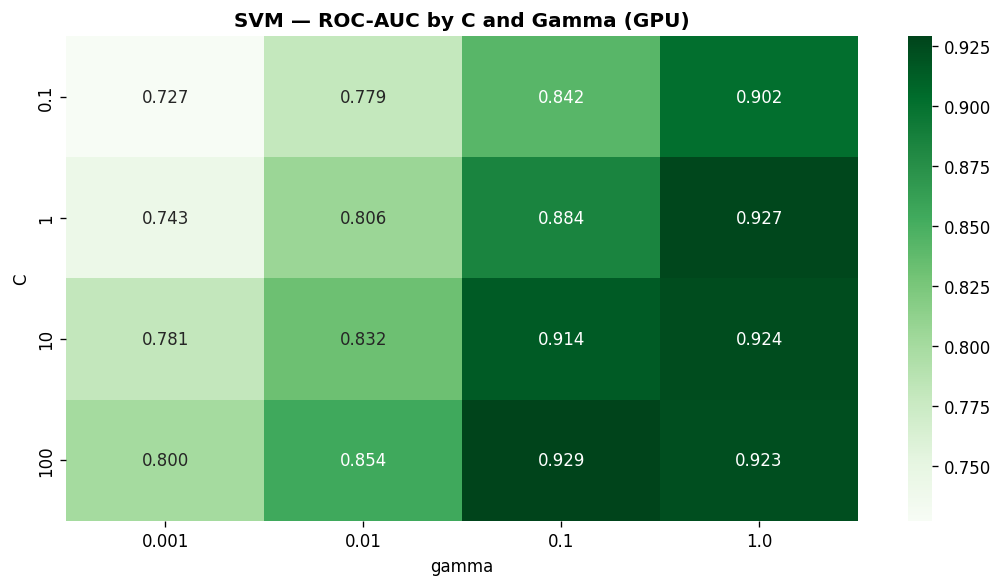

In [9]:
from sklearn.metrics import roc_auc_score

C_values     = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 'scale'] if not USE_GPU_SVM else [0.001, 0.01, 0.1, 1.0]

print(f"Sweeping C={C_values} x gamma={gamma_values} on {'GPU' if USE_GPU_SVM else 'CPU'}")
best_auc_svm = 0
svm_best     = svm_baseline
auc_grid     = np.zeros((len(C_values), len(gamma_values)))

for i, c in enumerate(C_values):
    for j, g in enumerate(gamma_values):
        if USE_GPU_SVM:
            _svm = SVM_CLASS(kernel='rbf', C=c, gamma=g, probability=True)
        else:
            from sklearn.svm import SVC as SkSVC
            _svm = SkSVC(kernel='rbf', C=c, gamma=g, probability=True,
                         class_weight='balanced', cache_size=2000)

        _svm.fit(X_tr_gpu, y_tr_gpu)

        # Fix: .get() on cupy BEFORE slicing
        _prob_raw = _svm.predict_proba(X_te_gpu)
        _prob     = to_numpy(_prob_raw)[:, 1]

        auc = roc_auc_score(y_test, _prob)
        auc_grid[i, j] = auc
        print(f"  C={str(c):<6} gamma={str(g):<8} AUC={auc:.4f}",
              "<-- best" if auc > best_auc_svm else "")
        if auc > best_auc_svm:
            best_auc_svm = auc
            svm_best     = _svm

print(f"\nBest SVM — ROC-AUC: {best_auc_svm:.4f}")

# C vs Gamma heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(auc_grid, annot=True, fmt=".3f", cmap="Greens",
            xticklabels=[str(g) for g in gamma_values],
            yticklabels=[str(c) for c in C_values])
plt.xlabel("gamma"); plt.ylabel("C")
plt.title(f"SVM — ROC-AUC by C and Gamma ({'GPU' if USE_GPU_SVM else 'CPU'})",
          fontweight="bold")
plt.tight_layout()
plt.savefig("svm_c_gamma_heatmap.png", bbox_inches="tight")
plt.show()


## 9. Cross-Validation (sklearn CPU)
5-fold CV on a CPU sklearn SVC using best C and gamma found above.
Uses a subset of 8K rows to keep CV feasible.

Running 5-fold CV with C=100, gamma=0.1
5-Fold CV ROC-AUC: [0.8489 0.8521 0.8472 0.8461 0.8407]
Mean ±Std: 0.847 ± 0.0037


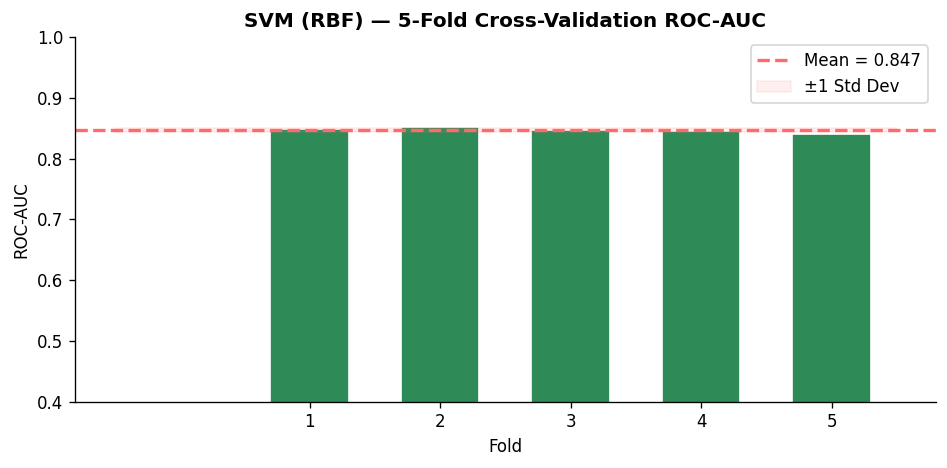

In [10]:
from sklearn.svm import SVC as SkSVC
from sklearn.model_selection import cross_val_score
import random as _rnd

# Extract best hyperparams
try:
    best_C_val   = svm_best.C
    best_g_val   = svm_best.gamma
except Exception:
    best_C_val, best_g_val = 1.0, 'scale'

print(f"Running 5-fold CV with C={best_C_val}, gamma={best_g_val}")

cv_model = SkSVC(C=best_C_val, gamma=best_g_val, kernel='rbf',
                 probability=True, class_weight='balanced', cache_size=2000)

# Subsample for speed
_rnd.seed(RANDOM_STATE)
cv_idx = _rnd.sample(range(len(X_train_scaled)), min(8000, len(X_train_scaled)))
X_cv   = X_train_scaled[cv_idx]
y_cv   = y_train.iloc[cv_idx]

cv_scores = cross_val_score(cv_model, X_cv, y_cv, cv=5,
                            scoring='roc_auc', n_jobs=-1)
print("5-Fold CV ROC-AUC:", cv_scores.round(4))
print("Mean ±Std:", round(cv_scores.mean(), 4), "±", round(cv_scores.std(), 4))

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='#2E8B57', edgecolor='white', width=0.6)
plt.axhline(cv_scores.mean(), color='#FF6B6B', lw=2, ls='--',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.fill_between([-0.5, 5.5],
                 [cv_scores.mean()-cv_scores.std()]*2,
                 [cv_scores.mean()+cv_scores.std()]*2,
                 alpha=0.1, color='#FF6B6B', label='±1 Std Dev')
plt.xlabel("Fold"); plt.ylabel("ROC-AUC"); plt.ylim(0.4, 1.0)
plt.xticks(range(1, 6))
plt.title("SVM (RBF) — 5-Fold Cross-Validation ROC-AUC", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("cv_SVM.png", bbox_inches="tight")
plt.show()


## 10. Save Model & Download
Saves the trained SVM model, scaler, features, and metadata as `.pkl` files.
Auto-downloads on Google Colab. On Jupyter use the file browser.

In [11]:
import joblib, json as _json, os
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.svm import SVC as SkSVC

# ── 1. Prepare portable sklearn model for saving ───────────────────────────────
# cuML SVC cannot be saved with joblib portably.
# Retrain a sklearn SVC with best params so the pkl loads on any machine.
if USE_GPU_SVM:
    print("Retraining sklearn SVC with best GPU-found params for portable saving...")
    try:
        best_C_save   = svm_best.C
        best_g_save   = svm_best.gamma
    except Exception:
        best_C_save, best_g_save = 1.0, 0.01

    svm_save = SkSVC(C=best_C_save, gamma=best_g_save, kernel='rbf',
                     probability=True, class_weight='balanced', cache_size=2000)
    svm_save.fit(X_train_scaled, y_train)   # fit on full numpy training set
    print(f"  sklearn SVC retrained — C={best_C_save}, gamma={best_g_save}")
else:
    svm_save = svm_best

# ── 2. Save model ──────────────────────────────────────────────────────────────
model_path = "svm_model.pkl"
joblib.dump(svm_save, model_path)
print("Model saved  ->", model_path, "(", round(os.path.getsize(model_path)/1024, 1), "KB)")
saved_files = [model_path]

# ── 3. Save scaler ────────────────────────────────────────────────────────────
scaler_path = "svm_scaler.pkl"
joblib.dump(scaler, scaler_path)
print("Scaler saved ->", scaler_path, "(", round(os.path.getsize(scaler_path)/1024, 1), "KB)")
saved_files.append(scaler_path)

# ── 4. Save features ──────────────────────────────────────────────────────────
joblib.dump(FEATURES, "svm_features.pkl")
print("Features saved -> svm_features.pkl")
saved_files.append("svm_features.pkl")

# ── 5. Compute metrics from saved sklearn model ────────────────────────────────
_pred   = svm_save.predict(X_test_scaled)
_prob   = svm_save.predict_proba(X_test_scaled)[:, 1]
acc_val = round(accuracy_score(y_test, _pred), 4)
f1_val  = round(f1_score(y_test, _pred, zero_division=0), 4)
roc_val = round(roc_auc_score(y_test, _prob), 4)
print(f"\nMetrics on test set:")
print(f"  Accuracy : {acc_val}")
print(f"  F1-Score : {f1_val}")
print(f"  ROC-AUC  : {roc_val}")

# ── 6. Save metadata ──────────────────────────────────────────────────────────
meta = {
    "algorithm"    : "SVM (RBF Kernel)",
    "model_file"   : "svm_model.pkl",
    "scaler_file"  : "svm_scaler.pkl",
    "needs_scaling": True,
    "features"     : FEATURES,
    "test_roc_auc" : roc_val,
    "test_f1"      : f1_val,
    "test_accuracy": acc_val,
}
with open("svm_metadata.json", "w") as f:
    _json.dump(meta, f, indent=2)
print("Metadata saved -> svm_metadata.json")
saved_files.append("svm_metadata.json")

# ── 7. File summary ───────────────────────────────────────────────────────────
print("\nFiles saved:")
for fp in saved_files:
    print(f"  {fp:<30} {round(os.path.getsize(fp)/1024, 1):>8.1f} KB")

# ── 8. Reload verification ────────────────────────────────────────────────────
_m   = joblib.load("svm_model.pkl")
_sc  = joblib.load("svm_scaler.pkl")
_chk = _m.predict(_sc.transform(X_test))
print(f"\nReload check — {type(_m).__name__} loaded OK | Accuracy: {round(accuracy_score(y_test, _chk), 4)}")

# ── 9. Download (Colab only) ──────────────────────────────────────────────────
try:
    from google.colab import files
    print("\nDownloading files...")
    for fp in saved_files:
        files.download(fp)
        print("  Downloaded:", fp)
except ImportError:
    print("\nNot running in Colab — download files manually:")
    print("  Right-click each file in the Jupyter file browser → Download")
    for fp in saved_files:
        print("  -", fp)


Retraining sklearn SVC with best GPU-found params for portable saving...
  sklearn SVC retrained — C=100, gamma=0.1
Model saved  -> svm_model.pkl ( 1496.9 KB)
Scaler saved -> svm_scaler.pkl ( 1.5 KB)
Features saved -> svm_features.pkl

Metrics on test set:
  Accuracy : 0.8789
  F1-Score : 0.8817
  ROC-AUC  : 0.9285
Metadata saved -> svm_metadata.json

Files saved:
  svm_model.pkl                    1496.9 KB
  svm_scaler.pkl                      1.5 KB
  svm_features.pkl                    0.3 KB
  svm_metadata.json                   0.5 KB

Reload check — SVC loaded OK | Accuracy: 0.8789



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: svm_model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: svm_features.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: svm_metadata.json
